<a href="https://colab.research.google.com/github/ver1812/Capstone_Project/blob/main/models/DeBERTaV3_Colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning — DeBERTa-v3-base



In [1]:
import os
import json
import time
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import transformers
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "transformers"], check=True)
    import transformers

try:
    import sentencepiece
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "sentencepiece"], check=True) #Tokeniser
    import sentencepiece


from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

print(f"transformers version: {transformers.__version__}")
print(f"torch version: {torch.__version__}")


transformers version: 5.13.1
torch version: 2.11.0+cu128


### Environment setup (Colab)

In [2]:
import platform

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("=== ENVIRONMENT CHECK ===")
print(f"Platform:       {platform.system()} {platform.machine()}")
print(f"IN_COLAB:       {IN_COLAB}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"GPU memory:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: no GPU detected — check Runtime > Change runtime type > GPU.")

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/Capstone" if IN_COLAB else ".."
DATA_DIR = f"{BASE_DIR}/data_v2"
print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")


=== ENVIRONMENT CHECK ===
Platform:       Linux x86_64
IN_COLAB:       True
CUDA available: True
GPU:            NVIDIA A100-SXM4-80GB
GPU memory:     85.1 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR: /content/drive/MyDrive/Capstone
DATA_DIR: /content/drive/MyDrive/Capstone/data_v2


### Config

In [3]:
SEED = 42

MODEL_NAME = "microsoft/deberta-v3-base"
MODEL_SLUG = "deberta_v3"   # used for the save folder + every artifact filename —


# Data
TEXT_COL = "text"
LABEL_COL = "label"


MAX_LEN = None

# Training — standard  defaults
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
MAX_EPOCHS = 8
PATIENCE = 3
GRAD_CLIP = 1.0
USE_AMP = True

# Artifacts — Capstone/saved/{MODEL_SLUG} on Drive
SAVE_DIR = f"{BASE_DIR}/saved/{MODEL_SLUG}"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = USE_AMP and DEVICE.type == "cuda"
# ------------------------------------------------------------------


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Model: {MODEL_NAME}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"Save dir: {SAVE_DIR}")


Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Model: microsoft/deberta-v3-base
AMP enabled: True
Save dir: /content/drive/MyDrive/Capstone/saved/deberta_v3


In [4]:
TRAIN_PATH = f"{DATA_DIR}/train_v2.csv"
VAL_PATH   = f"{DATA_DIR}/val_v2.csv"
TEST_PATH  = f"{DATA_DIR}/test_v2.csv"

for _name, _path in [("train_v2.csv", TRAIN_PATH), ("val_v2.csv", VAL_PATH), ("test_v2.csv", TEST_PATH)]:
    if not os.path.exists(_path):
        raise FileNotFoundError(
            f"{_name} not found at {_path} — check DATA_DIR is correct and the "
            "files actually live in that Drive folder."
        )


def load_split(path, text_col, label_col):
    frame = pd.read_csv(path)
    frame[text_col] = frame[text_col].fillna("").astype(str)
    frame[label_col] = frame[label_col].astype(int)
    return frame


train_df = load_split(TRAIN_PATH, TEXT_COL, LABEL_COL)
val_df   = load_split(VAL_PATH,   TEXT_COL, LABEL_COL)
test_df  = load_split(TEST_PATH,  TEXT_COL, LABEL_COL)

for name, frame in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:<6} {len(frame):>7,} rows | {frame[LABEL_COL].mean():.4f} positive")


Train   14,429 rows | 0.4784 positive
Val      3,092 rows | 0.4783 positive
Test     3,093 rows | 0.4785 positive


### Tokenizer & sequence length
The WordPiece tokenizer produces a different length distribution than the BiLSTM's word-level tokenizer — re-checking coverage here rather than assuming the earlier analysis carries over. Unlike the BiLSTM, there's no length to *choose* past 512 — this only tells you how much gets cut off.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Real token counts with NO truncation, to see the true distribution
train_encodings_full = tokenizer(list(train_df[TEXT_COL]), truncation=False)
train_lengths = np.array([len(ids) for ids in train_encodings_full["input_ids"]])

percentiles = [50, 75, 90, 95, 97, 99]
print(f"SentencePiece token-length percentiles (train set, {MODEL_NAME} tokenizer):")
for p in percentiles:
    print(f"  p{p:>2}: {int(np.percentile(train_lengths, p)):>6,}")
print(f"  max: {train_lengths.max():>6,}")
print(f" mean: {train_lengths.mean():>6.1f}")

del train_encodings_full  # free memory — only needed the lengths


SentencePiece token-length percentiles (train set, microsoft/deberta-v3-base tokenizer):
  p50:    116
  p75:    193
  p90:    354
  p95:    864
  p97:  1,037
  p99:  2,506
  max:  4,732
 mean:  217.6


In [6]:
MAX_LEN = 512  # Max available
coverage_overall = (train_lengths <= MAX_LEN).mean()
coverage_benign = (train_lengths[train_df[LABEL_COL].values == 0] <= MAX_LEN).mean()
coverage_malicious = (train_lengths[train_df[LABEL_COL].values == 1] <= MAX_LEN).mean()

print(f"MAX_LEN = {MAX_LEN}")
print(f"Overall coverage:   {coverage_overall:.2%}")
print(f"Benign coverage:    {coverage_benign:.2%}")
print(f"Malicious coverage: {coverage_malicious:.2%}")


MAX_LEN = 512
Overall coverage:   92.93%
Benign coverage:    92.98%
Malicious coverage: 92.87%


### Dataset & DataLoader (dynamic padding)
Sequences are tokenized to variable length (no fixed padding here) and padded per-batch by `DataCollatorWithPadding` —

In [7]:
class TransformerPromptDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, max_length=max_len, padding=False)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

train_ds = TransformerPromptDataset(train_df[TEXT_COL], train_df[LABEL_COL], tokenizer, MAX_LEN)
val_ds   = TransformerPromptDataset(val_df[TEXT_COL],   val_df[LABEL_COL],   tokenizer, MAX_LEN)
test_ds  = TransformerPromptDataset(test_df[TEXT_COL],  test_df[LABEL_COL],  tokenizer, MAX_LEN)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator, collate_fn=data_collator)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches — train: 902, val: 194, test: 194


### Model

In [8]:
# loss is computed manually below with BCEWithLogitsLoss +
# pos_weight, same as every other model in this project.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=1, torch_dtype=torch.float32
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model on device: {next(model.parameters()).device}")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

Total parameters:     184,422,913
Trainable parameters: 184,422,913
Model on device: cuda:0


### Loss, optimizer, scheduler

In [9]:
num_neg = int((train_df[LABEL_COL] == 0).sum())
num_pos = int((train_df[LABEL_COL] == 1).sum())
pos_weight_value = num_neg / num_pos

print(f"Negatives: {num_neg:,} | Positives: {num_pos:,}")
print(f"pos_weight = {pos_weight_value:.4f}")

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print(f"Total optimizer steps: {total_steps:,} (warmup: {warmup_steps:,})")


Negatives: 7,526 | Positives: 6,903
pos_weight = 1.0903
Total optimizer steps: 7,216 (warmup: 721)


/tmp/ipykernel_9915/3435023473.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


### Train and evaluate functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device, grad_clip, epoch_num, total_epochs, print_every=40):
    model.train()
    running_loss = 0.0
    n_batches = len(loader)
    batch_start = time.time()
    skipped_batches = 0

    for batch_idx, batch in enumerate(loader, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.squeeze(-1)
            loss = criterion(logits, labels)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  [Epoch {epoch_num}] batch {batch_idx}: NaN/Inf loss detected — skipping batch (no backward call)")
            skipped_batches += 1
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        if torch.isnan(grad_norm) or torch.isinf(grad_norm):
            print(f"  [Epoch {epoch_num}] batch {batch_idx}: NaN/Inf gradient — GradScaler will skip this optimizer step")
            skipped_batches += 1

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * input_ids.size(0)

        if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == n_batches:
            elapsed = time.time() - batch_start
            avg_batch_time = elapsed / batch_idx
            eta_sec = avg_batch_time * (n_batches - batch_idx)
            print(
                f"  [Epoch {epoch_num}/{total_epochs}] batch {batch_idx}/{n_batches} "
                f"| loss {loss.item():.4f} | {avg_batch_time:.2f}s/batch | ETA {eta_sec:.0f}s",
                flush=True,
            )

    if skipped_batches > 0:
        print(f"  Epoch {epoch_num}: {skipped_batches} batch(es) skipped due to numerical instability")

    return running_loss / len(loader.dataset)


def predict(model, loader, criterion, device, desc="eval"):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits.squeeze(-1)
                loss = criterion(logits, labels)

            running_loss += loss.item() * input_ids.size(0)

            probs = torch.sigmoid(logits.float())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, np.concatenate(all_labels), np.concatenate(all_probs)


### Helper functions

In [11]:
def evaluate_predictions(y_true, y_prob, threshold=0.5, split_name=""):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }


def print_metrics(metrics):
    print(f"--- {metrics['split']} (threshold={metrics['threshold']:.2f}) ---")
    for key in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
        print(f"  {key:<10}: {metrics[key]:.4f}")


Quick timing check before committing to the full run

In [12]:
print(next(model.parameters()).dtype)

torch.float32


In [13]:
model.train()
single_batch = next(iter(train_loader))
input_ids = single_batch["input_ids"].to(DEVICE)
attention_mask = single_batch["attention_mask"].to(DEVICE)
labels = single_batch["labels"].to(DEVICE)

start = time.time()
optimizer.zero_grad()
with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits.squeeze(-1)
    loss = criterion(logits, labels)
scaler.scale(loss).backward()
scaler.unscale_(optimizer)
nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
scaler.step(optimizer)
scaler.update()
scheduler.step()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
batch_time = time.time() - start

print(f"Single batch time ({DEVICE}, AMP={AMP_ENABLED}, MAX_LEN={MAX_LEN}, batch={BATCH_SIZE}): {batch_time:.3f}s")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Rough epoch estimate: {batch_time * len(train_loader) / 60:.1f} min")
print(f"Rough {MAX_EPOCHS}-epoch estimate: {batch_time * len(train_loader) * MAX_EPOCHS / 60:.1f} min")


/tmp/ipykernel_9915/3609877095.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Single batch time (cuda, AMP=True, MAX_LEN=512, batch=16): 0.965s
Batches per epoch: 902
Rough epoch estimate: 14.5 min
Rough 8-epoch estimate: 116.1 min


### Training loop

In [14]:
best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0
history = []

checkpoint_dir = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_best")

print(f"Starting training — up to {MAX_EPOCHS} epochs, early stopping patience={PATIENCE}\n")

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler,
        DEVICE, GRAD_CLIP, epoch, MAX_EPOCHS
    )
    val_loss, val_true, val_prob = predict(model, val_loader, criterion, DEVICE, desc=f"Epoch {epoch}/{MAX_EPOCHS} [val]")
    val_metrics = evaluate_predictions(val_true, val_prob, 0.5, "val")

    elapsed = time.time() - start

    history.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        "val_f1": val_metrics["f1"], "val_recall": val_metrics["recall"],
        "val_precision": val_metrics["precision"], "seconds": elapsed,
    })

    print(
        f"Epoch {epoch:>2}/{MAX_EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
        f"| val_F1 {val_metrics['f1']:.4f} | val_recall {val_metrics['recall']:.4f} | {elapsed:.1f}s"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        model.save_pretrained(checkpoint_dir)
        tokenizer.save_pretrained(checkpoint_dir)
        print("         -> new best val F1, checkpoint saved")
    else:
        epochs_without_improvement += 1
        print(f"         -> no improvement ({epochs_without_improvement}/{PATIENCE})")
        if epochs_without_improvement >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}, best val F1: {best_val_f1:.4f}.")
            break

history_df = pd.DataFrame(history)
print(f"\nTraining complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")


Starting training — up to 8 epochs, early stopping patience=3



/tmp/ipykernel_9915/433618047.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


  [Epoch 1/8] batch 1/902 | loss 0.6775 | 0.48s/batch | ETA 433s
  [Epoch 1/8] batch 40/902 | loss 0.7312 | 0.18s/batch | ETA 152s
  [Epoch 1] batch 76: NaN/Inf gradient — GradScaler will skip this optimizer step
  [Epoch 1/8] batch 80/902 | loss 0.7172 | 0.16s/batch | ETA 135s
  [Epoch 1/8] batch 120/902 | loss 0.7069 | 0.16s/batch | ETA 124s
  [Epoch 1/8] batch 160/902 | loss 0.5556 | 0.16s/batch | ETA 116s
  [Epoch 1/8] batch 200/902 | loss 0.5333 | 0.16s/batch | ETA 109s
  [Epoch 1/8] batch 240/902 | loss 0.3906 | 0.15s/batch | ETA 102s
  [Epoch 1/8] batch 280/902 | loss 0.3203 | 0.15s/batch | ETA 95s
  [Epoch 1/8] batch 320/902 | loss 0.4550 | 0.15s/batch | ETA 89s
  [Epoch 1] batch 359: NaN/Inf gradient — GradScaler will skip this optimizer step
  [Epoch 1/8] batch 360/902 | loss 0.2334 | 0.15s/batch | ETA 83s
  [Epoch 1/8] batch 400/902 | loss 0.0695 | 0.15s/batch | ETA 77s
  [Epoch 1/8] batch 440/902 | loss 0.0598 | 0.15s/batch | ETA 70s
  [Epoch 1] batch 446: NaN/Inf gradient 

/tmp/ipykernel_9915/433618047.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch  1/8 | train_loss 0.3616 | val_loss 0.2222 | val_F1 0.9409 | val_recall 0.9101 | 147.5s


...

Epoch  7/8 | train_loss 0.0529 | val_loss 0.2580 | val_F1 0.9512 | val_recall 0.9297 | 146.2s
         -> no improvement (2/3)
  [Epoch 8/8] batch 1/902 | loss 0.0057 | 0.17s/batch | ETA 152s


/tmp/ipykernel_9915/433618047.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


  [Epoch 8/8] batch 40/902 | loss 0.0002 | 0.14s/batch | ETA 124s
  [Epoch 8/8] batch 80/902 | loss 0.0043 | 0.15s/batch | ETA 120s
  [Epoch 8/8] batch 120/902 | loss 0.0015 | 0.15s/batch | ETA 115s
  [Epoch 8/8] batch 160/902 | loss 0.6060 | 0.15s/batch | ETA 110s
  [Epoch 8/8] batch 200/902 | loss 0.0038 | 0.15s/batch | ETA 104s
  [Epoch 8/8] batch 240/902 | loss 0.1336 | 0.15s/batch | ETA 99s
  [Epoch 8/8] batch 280/902 | loss 0.0037 | 0.15s/batch | ETA 93s
  [Epoch 8/8] batch 320/902 | loss 0.0005 | 0.15s/batch | ETA 87s
  [Epoch 8/8] batch 360/902 | loss 0.2381 | 0.15s/batch | ETA 81s
  [Epoch 8/8] batch 400/902 | loss 0.0003 | 0.15s/batch | ETA 75s
  [Epoch 8/8] batch 440/902 | loss 0.8609 | 0.15s/batch | ETA 69s
  [Epoch 8/8] batch 480/902 | loss 0.0070 | 0.15s/batch | ETA 63s
  [Epoch 8/8] batch 520/902 | loss 0.0035 | 0.15s/batch | ETA 57s
  [Epoch 8/8] batch 560/902 | loss 0.0427 | 0.15s/batch | ETA 51s
  [Epoch 8/8] batch 600/902 | loss 0.0142 | 0.15s/batch | ETA 45s
  [Epoc

/tmp/ipykernel_9915/433618047.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch  8/8 | train_loss 0.0420 | val_loss 0.2813 | val_F1 0.9516 | val_recall 0.9304 | 146.0s
         -> no improvement (3/3)

Early stopping at epoch 8. Best epoch: 5, best val F1: 0.9530.

Training complete. Best val F1 = 0.9530 at epoch 5


Training curves

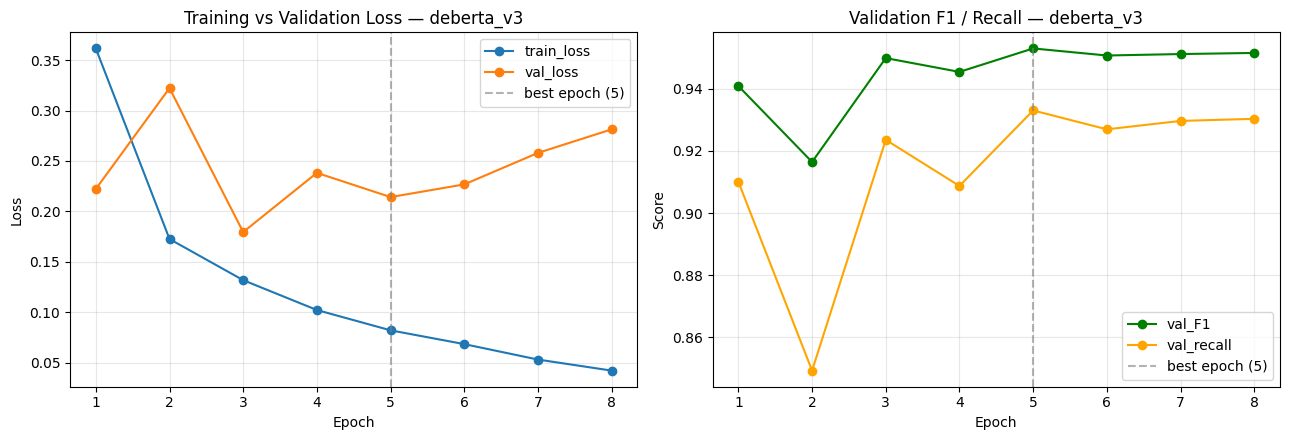

Saved: /content/drive/MyDrive/Capstone/saved/deberta_v3/loss_curve_deberta_v3.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
axes[0].axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"best epoch ({best_epoch})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(f"Training vs Validation Loss — {MODEL_SLUG}")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_f1"], marker="o", color="green", label="val_F1")
axes[1].plot(history_df["epoch"], history_df["val_recall"], marker="o", color="orange", label="val_recall")
axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"best epoch ({best_epoch})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title(f"Validation F1 / Recall — {MODEL_SLUG}")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
loss_curve_path = os.path.join(SAVE_DIR, f"loss_curve_{MODEL_SLUG}.png")
plt.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {loss_curve_path}")


### Load checkpoint and evaluate

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint_dir, torch_dtype=torch.float32
).to(DEVICE)

_, val_true, val_prob = predict(model, val_loader, criterion, DEVICE, desc="final val")
val_metrics = evaluate_predictions(val_true, val_prob, 0.5, "val")
print_metrics(val_metrics)

_, test_true, test_prob = predict(model, test_loader, criterion, DEVICE, desc="final test")
test_metrics = evaluate_predictions(test_true, test_prob, 0.5, "test")
print_metrics(test_metrics)

print("\nConfusion matrix (test, threshold=0.5):")
test_pred = (test_prob >= 0.5).astype(int)
cm = confusion_matrix(test_true, test_pred)
print(pd.DataFrame(cm, index=["actual_benign", "actual_malicious"], columns=["pred_benign", "pred_malicious"]))

print("\n" + classification_report(test_true, test_pred, digits=4))


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

/tmp/ipykernel_9915/433618047.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


--- val (threshold=0.50) ---
  accuracy  : 0.9560
  precision : 0.9739
  recall    : 0.9331
  f1        : 0.9530
  roc_auc   : 0.9857
  pr_auc    : 0.9875


/tmp/ipykernel_9915/433618047.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


--- test (threshold=0.50) ---
  accuracy  : 0.9509
  precision : 0.9723
  recall    : 0.9236
  f1        : 0.9473
  roc_auc   : 0.9841
  pr_auc    : 0.9866

Confusion matrix (test, threshold=0.5):
                  pred_benign  pred_malicious
actual_benign            1574              39
actual_malicious          113            1367

              precision    recall  f1-score   support

         0.0     0.9330    0.9758    0.9539      1613
         1.0     0.9723    0.9236    0.9473      1480

    accuracy                         0.9509      3093
   macro avg     0.9526    0.9497    0.9506      3093
weighted avg     0.9518    0.9509    0.9508      3093



ROC curve

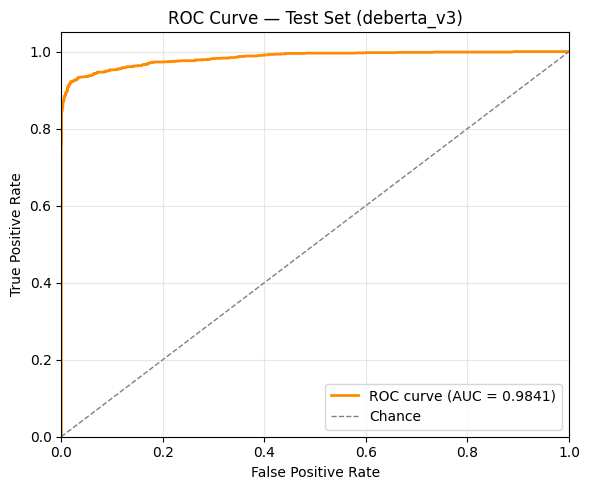

Saved: /content/drive/MyDrive/Capstone/saved/deberta_v3/roc_curve_deberta_v3.png


In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(test_true, test_prob)
roc_auc_value = test_metrics["roc_auc"]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — Test Set ({MODEL_SLUG})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(SAVE_DIR, f"roc_curve_{MODEL_SLUG}.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {roc_path}")


Confusion matrix (visual)

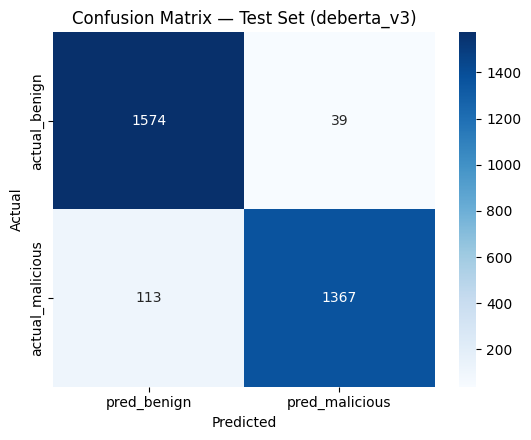

Saved: /content/drive/MyDrive/Capstone/saved/deberta_v3/confusion_matrix_deberta_v3.png


In [18]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Test Set ({MODEL_SLUG})")
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, f"confusion_matrix_{MODEL_SLUG}.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")


Confusion matrix (visual) — validation set

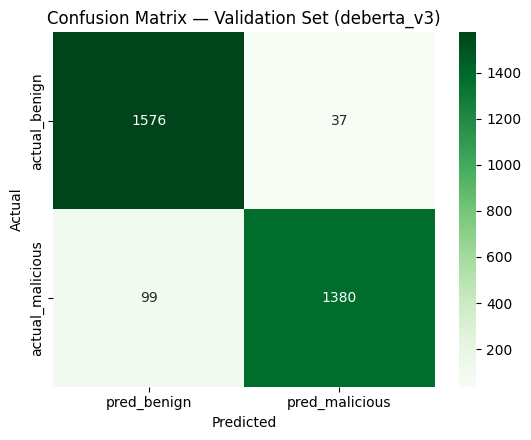

Saved: /content/drive/MyDrive/Capstone/saved/deberta_v3/confusion_matrix_val_deberta_v3.png


In [19]:
val_pred = (val_prob >= 0.5).astype(int)
val_cm = confusion_matrix(val_true, val_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    val_cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Validation Set ({MODEL_SLUG})")
plt.tight_layout()

val_cm_path = os.path.join(SAVE_DIR, f"confusion_matrix_val_{MODEL_SLUG}.png")
plt.savefig(val_cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {val_cm_path}")


### Save metrics/history

In [20]:
config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "model_slug": MODEL_SLUG,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "warmup_ratio": WARMUP_RATIO,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "grad_clip": GRAD_CLIP,
    "amp_enabled": AMP_ENABLED,
    "pos_weight": pos_weight_value,
    "best_epoch": best_epoch,
    "best_val_f1": best_val_f1,
    "total_params": total_params,
    "trainable_params": trainable_params,
    "device": str(DEVICE),
}
with open(os.path.join(SAVE_DIR, f"config_{MODEL_SLUG}.json"), "w") as f:
    json.dump(config, f, indent=2)

results = pd.DataFrame([val_metrics, test_metrics])
results.to_csv(os.path.join(SAVE_DIR, f"metrics_{MODEL_SLUG}.csv"), index=False)
history_df.to_csv(os.path.join(SAVE_DIR, f"history_{MODEL_SLUG}.csv"), index=False)

print("Saved:")
for root, dirs, files in os.walk(SAVE_DIR):
    for f in files:
        print(f"  {os.path.join(root, f)}")

results


Saved:
  /content/drive/MyDrive/Capstone/saved/deberta_v3/loss_curve_deberta_v3.png
  /content/drive/MyDrive/Capstone/saved/deberta_v3/roc_curve_deberta_v3.png
  /content/drive/MyDrive/Capstone/saved/deberta_v3/confusion_matrix_deberta_v3.png
  /content/drive/MyDrive/Capstone/saved/deberta_v3/confusion_matrix_val_deberta_v3.png
  /content/drive/MyDrive/Capstone/saved/deberta_v3/config_deberta_v3.json
  /content/drive/MyDrive/Capstone/saved/deberta_v3/metrics_deberta_v3.csv
  /content/drive/MyDrive/Capstone/saved/deberta_v3/history_deberta_v3.csv
  /content/drive/MyDrive/Capstone/saved/deberta_v3/deberta_v3_best/config.json
  /content/drive/MyDrive/Capstone/saved/deberta_v3/deberta_v3_best/model.safetensors
  /content/drive/MyDrive/Capstone/saved/deberta_v3/deberta_v3_best/tokenizer_config.json
  /content/drive/MyDrive/Capstone/saved/deberta_v3/deberta_v3_best/tokenizer.json


,split,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,val,0.5,0.956016,0.973888,0.933063,0.953039,0.985677,0.987537
1,test,0.5,0.950857,0.972262,0.923649,0.947332,0.984109,0.986591


Results summary (JSON, matches the traditional ML / BiLSTM v2 format — includes raw confusion-matrix counts)

In [21]:
tn, fp, fn, tp = cm.ravel()
val_tn, val_fp, val_fn, val_tp = val_cm.ravel()

results_summary = {
    MODEL_SLUG: {
        "config": MODEL_SLUG,
        "validation": val_metrics,
        "test": test_metrics,
        "validation_confusion_matrix": {
            "tn": int(val_tn), "fp": int(val_fp), "fn": int(val_fn), "tp": int(val_tp),
        },
        "test_confusion_matrix": {
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        },
    }
}

results_json_path = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_results.json")
with open(results_json_path, "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"Saved results summary to {results_json_path}")
print(f"Test:       TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Validation: TN={val_tn}, FP={val_fp}, FN={val_fn}, TP={val_tp}")


Saved results summary to /content/drive/MyDrive/Capstone/saved/deberta_v3/deberta_v3_results.json
Test:       TN=1574, FP=39, FN=113, TP=1367
Validation: TN=1576, FP=37, FN=99, TP=1380


 threshold  accuracy  precision  recall     f1  FN  FP
      0.05    0.9279     0.8970  0.9594 0.9271  60 163
      0.10    0.9408     0.9274  0.9506 0.9389  73 110
      0.15    0.9470     0.9452  0.9439 0.9445  83  81
      0.20    0.9547     0.9672  0.9371 0.9519  93  47
      0.25    0.9550     0.9692  0.9358 0.9522  95  44
      0.30    0.9557     0.9712  0.9351 0.9528  96  41
      0.35    0.9557     0.9712  0.9351 0.9528  96  41
      0.40    0.9557     0.9725  0.9337 0.9527  98  39
      0.45    0.9560     0.9732  0.9337 0.9531  98  38
      0.50    0.9560     0.9739  0.9331 0.9530  99  37
      0.55    0.9557     0.9739  0.9324 0.9527 100  37
      0.60    0.9557     0.9739  0.9324 0.9527 100  37
      0.65    0.9557     0.9739  0.9324 0.9527 100  37
      0.70    0.9557     0.9739  0.9324 0.9527 100  37
      0.75    0.9563     0.9759  0.9317 0.9533 101  34
      0.80    0.9557     0.9772  0.9290 0.9525 105  32
      0.85    0.9554     0.9779  0.9277 0.9521 107  31
      0.90

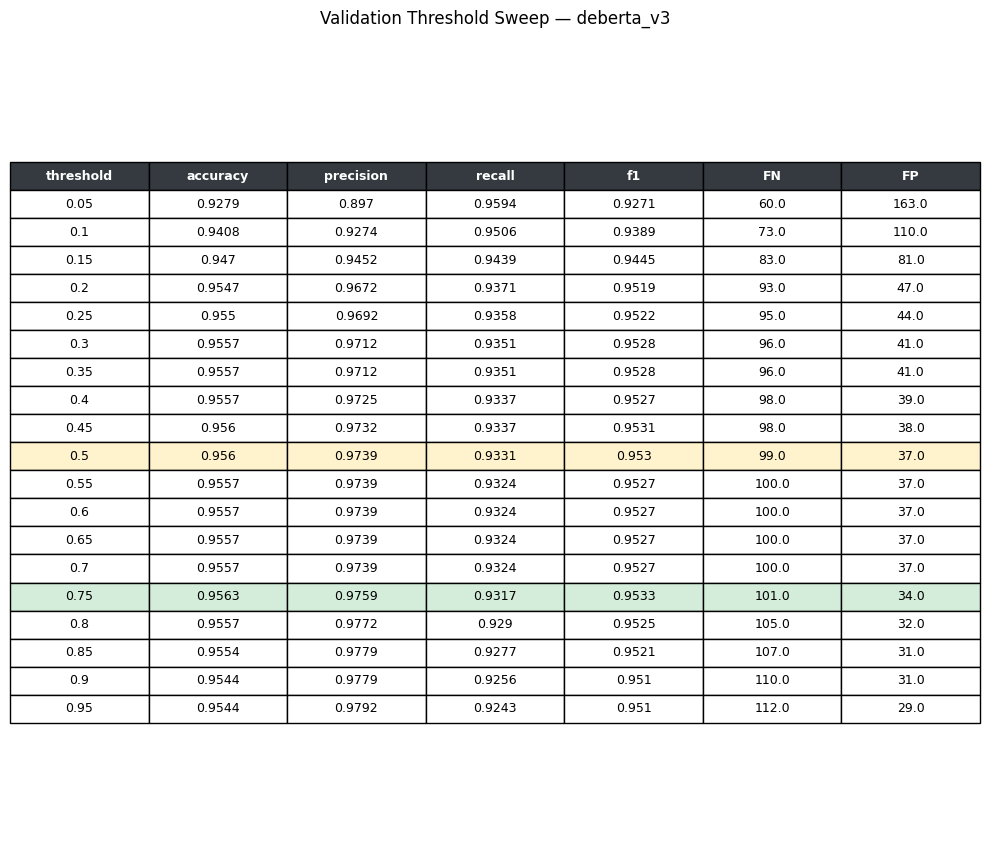

Saved: /content/drive/MyDrive/Capstone/saved/deberta_v3/threshold_sweep_table_deberta_v3.png


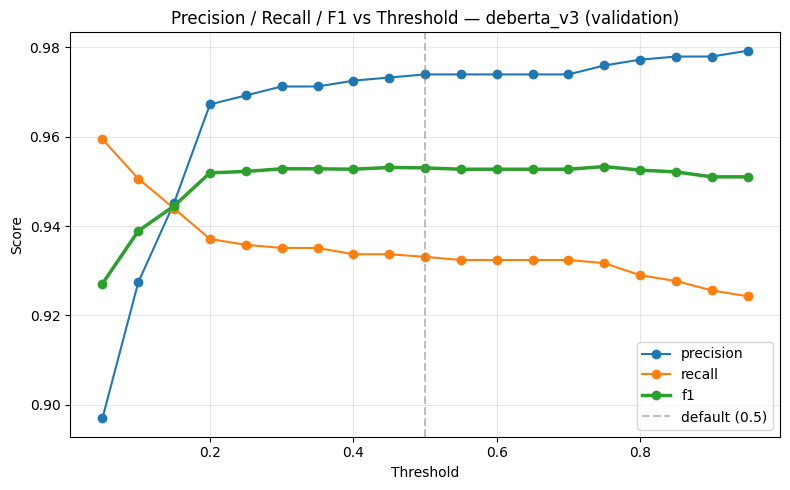

Saved: /content/drive/MyDrive/Capstone/saved/deberta_v3/threshold_tradeoff_deberta_v3.png


In [22]:
thresholds_to_check = np.arange(0.05, 0.96, 0.05)

sweep_rows = []
for t in thresholds_to_check:
    m = evaluate_predictions(val_true, val_prob, threshold=t, split_name="val")
    pred = (val_prob >= t).astype(int)
    fn = int(((val_true == 1) & (pred == 0)).sum())
    fp = int(((val_true == 0) & (pred == 1)).sum())
    sweep_rows.append({
        "threshold": round(float(t), 2),
        "accuracy": round(m["accuracy"], 4),
        "precision": round(m["precision"], 4),
        "recall": round(m["recall"], 4),
        "f1": round(m["f1"], 4),
        "FN": fn,
        "FP": fp,
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

# --- Graphic table ---
fig, ax = plt.subplots(figsize=(10, 0.4 * len(sweep_df) + 1))
ax.axis("off")

table = ax.table(
    cellText=sweep_df.values,
    colLabels=sweep_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

default_idx = sweep_df.index[sweep_df["threshold"] == 0.50].tolist()
if default_idx:
    for col in range(len(sweep_df.columns)):
        table[(default_idx[0] + 1, col)].set_facecolor("#FFF3CD")

best_f1_idx = int(sweep_df["f1"].idxmax())
for col in range(len(sweep_df.columns)):
    table[(best_f1_idx + 1, col)].set_facecolor("#D4EDDA")

for col in range(len(sweep_df.columns)):
    table[(0, col)].set_facecolor("#343A40")
    table[(0, col)].set_text_props(color="white", weight="bold")

plt.title(f"Validation Threshold Sweep — {MODEL_SLUG}", fontsize=12, pad=15)
plt.tight_layout()

sweep_table_path = os.path.join(SAVE_DIR, f"threshold_sweep_table_{MODEL_SLUG}.png")
plt.savefig(sweep_table_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {sweep_table_path}")

# --- Tradeoff curve ---
plt.figure(figsize=(8, 5))
plt.plot(sweep_df["threshold"], sweep_df["precision"], marker="o", label="precision")
plt.plot(sweep_df["threshold"], sweep_df["recall"], marker="o", label="recall")
plt.plot(sweep_df["threshold"], sweep_df["f1"], marker="o", label="f1", linewidth=2.5)
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall / F1 vs Threshold — {MODEL_SLUG} (validation)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

tradeoff_path = os.path.join(SAVE_DIR, f"threshold_tradeoff_{MODEL_SLUG}.png")
plt.savefig(tradeoff_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {tradeoff_path}")

--- val @ 0.3 (threshold=0.30) ---
  accuracy  : 0.9557
  precision : 0.9712
  recall    : 0.9351
  f1        : 0.9528
  roc_auc   : 0.9857
  pr_auc    : 0.9875
--- test @ 0.3 (threshold=0.30) ---
  accuracy  : 0.9505
  precision : 0.9696
  recall    : 0.9257
  f1        : 0.9471
  roc_auc   : 0.9841
  pr_auc    : 0.9866

Classification report (test @ 0.3):
              precision    recall  f1-score   support

         0.0     0.9345    0.9733    0.9535      1613
         1.0     0.9696    0.9257    0.9471      1480

    accuracy                         0.9505      3093
   macro avg     0.9520    0.9495    0.9503      3093
weighted avg     0.9513    0.9505    0.9505      3093



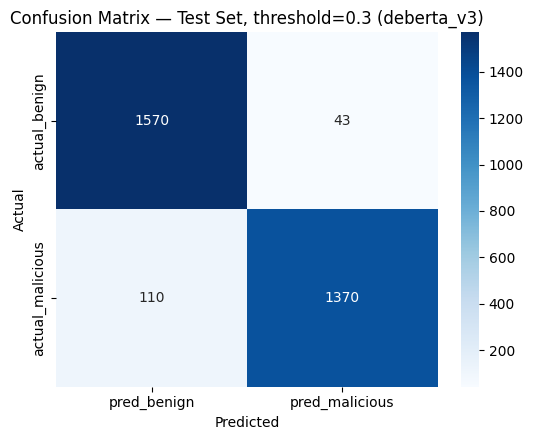

Saved: /content/drive/MyDrive/Capstone/saved/deberta_v3/confusion_matrix_tuned_deberta_v3.png


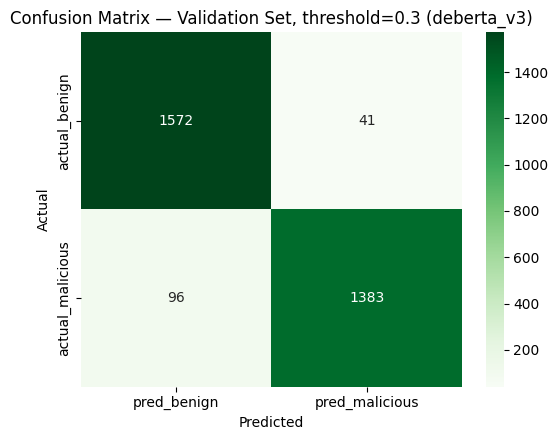

Saved: /content/drive/MyDrive/Capstone/saved/deberta_v3/confusion_matrix_val_tuned_deberta_v3.png

Test set — default vs. tuned:
       config  accuracy  precision  recall     f1
default (0.5)    0.9509     0.9723  0.9236 0.9473
  tuned (0.3)    0.9505     0.9696  0.9257 0.9471

FN: 113 (default) -> 110 (tuned 0.3)
FP: 39 (default) -> 43 (tuned 0.3)

Saved tuned-threshold results to /content/drive/MyDrive/Capstone/saved/deberta_v3/deberta_v3_results_threshold0.3.json


In [23]:
CHOSEN_THRESHOLD = 0.30

# --- Full metrics at the tuned threshold, both splits ---
val_metrics_tuned = evaluate_predictions(val_true, val_prob, threshold=CHOSEN_THRESHOLD, split_name=f"val @ {CHOSEN_THRESHOLD}")
test_metrics_tuned = evaluate_predictions(test_true, test_prob, threshold=CHOSEN_THRESHOLD, split_name=f"test @ {CHOSEN_THRESHOLD}")

print_metrics(val_metrics_tuned)
print_metrics(test_metrics_tuned)

test_pred_tuned = (test_prob >= CHOSEN_THRESHOLD).astype(int)
val_pred_tuned = (val_prob >= CHOSEN_THRESHOLD).astype(int)

cm_tuned = confusion_matrix(test_true, test_pred_tuned)
val_cm_tuned = confusion_matrix(val_true, val_pred_tuned)

print(f"\nClassification report (test @ {CHOSEN_THRESHOLD}):")
print(classification_report(test_true, test_pred_tuned, digits=4))

# --- Confusion matrix visual, test ---
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm_tuned, annot=True, fmt="d", cmap="Blues",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Test Set, threshold={CHOSEN_THRESHOLD} ({MODEL_SLUG})")
plt.tight_layout()
cm_tuned_path = os.path.join(SAVE_DIR, f"confusion_matrix_tuned_{MODEL_SLUG}.png")
plt.savefig(cm_tuned_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_tuned_path}")

# --- Confusion matrix visual, validation ---
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    val_cm_tuned, annot=True, fmt="d", cmap="Greens",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Validation Set, threshold={CHOSEN_THRESHOLD} ({MODEL_SLUG})")
plt.tight_layout()
val_cm_tuned_path = os.path.join(SAVE_DIR, f"confusion_matrix_val_tuned_{MODEL_SLUG}.png")
plt.savefig(val_cm_tuned_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {val_cm_tuned_path}")

# --- Direct before/after comparison at a glance ---
comparison = pd.DataFrame([
    {"config": "default (0.5)", **evaluate_predictions(test_true, test_prob, 0.5, "test")},
    {"config": f"tuned ({CHOSEN_THRESHOLD})", **evaluate_predictions(test_true, test_prob, CHOSEN_THRESHOLD, "test")},
])
print("\nTest set — default vs. tuned:")
print(comparison[["config", "accuracy", "precision", "recall", "f1"]].round(4).to_string(index=False))

tn, fp, fn, tp = confusion_matrix(test_true, (test_prob >= 0.5).astype(int)).ravel()
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()
print(f"\nFN: {fn} (default) -> {fn_t} (tuned {CHOSEN_THRESHOLD})")
print(f"FP: {fp} (default) -> {fp_t} (tuned {CHOSEN_THRESHOLD})")

# --- Separate JSON for the tuned threshold — keeps deberta_v3_results.json (default 0.5) intact ---
val_tn, val_fp, val_fn, val_tp = val_cm_tuned.ravel()

results_summary_tuned = {
    MODEL_SLUG: {
        "config": f"{MODEL_SLUG}_threshold{CHOSEN_THRESHOLD}",
        "threshold": CHOSEN_THRESHOLD,
        "validation": val_metrics_tuned,
        "test": test_metrics_tuned,
        "validation_confusion_matrix": {"tn": int(val_tn), "fp": int(val_fp), "fn": int(val_fn), "tp": int(val_tp)},
        "test_confusion_matrix": {"tn": int(tn_t), "fp": int(fp_t), "fn": int(fn_t), "tp": int(tp_t)},
    }
}

results_json_tuned_path = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_results_threshold{CHOSEN_THRESHOLD}.json")
with open(results_json_tuned_path, "w") as f:
    json.dump(results_summary_tuned, f, indent=2)

print(f"\nSaved tuned-threshold results to {results_json_tuned_path}")

Zip artifacts for download

In [24]:
import shutil

zip_path = shutil.make_archive(
    base_name=f"{BASE_DIR}/{MODEL_SLUG}_artifacts",
    format="zip",
    root_dir=SAVE_DIR,
)
print(f"Zipped to: {zip_path}")
print(f"Size: {os.path.getsize(zip_path) / 1e6:.2f} MB")


Zipped to: /content/drive/MyDrive/Capstone/deberta_v3_artifacts.zip
Size: 603.35 MB
